In [1]:
# 1. 필요 라이브러리 호출 및 시각화 기본 설정
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import platform

# 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

print("라이브러리 호출 및 시각화 폰트 설정 완료")

라이브러리 호출 및 시각화 폰트 설정 완료


In [2]:
# 2. 전처리가 완료된 데이터셋 불러오기
print("데이터를 불러오는 중입니다...")

df = pd.read_csv('final_dataset.csv', low_memory=False)

print(f"데이터 불러오기 완료! (총 {len(df):,}건)")

데이터를 불러오는 중입니다...
데이터 불러오기 완료! (총 12,454건)


In [3]:
# 3. 시각화를 위한 범주형 변수 추가 정제

# ① 단지내_편의시설_유무 생성
if '부대복리시설' in df.columns and '단지내_편의시설_유무' not in df.columns:
    df['단지내_편의시설_유무'] = df['부대복리시설'].apply(
        lambda x: 0 if pd.isna(x) or str(x).strip().lower() == 'nan' else 1
    )

# ② 복도유형 텍스트 공백 제거 및 기타 처리
if '복도유형' in df.columns:
    df['복도유형'] = df['복도유형'].astype(str).str.strip() 
    df.loc[~df['복도유형'].isin(['계단식', '복도식', '혼합식']), '복도유형'] = '기타'

# ③ 분석 대상 변수 리스트 셋업
target = '거래금액_만원'
features = [
    '전용면적', '건물나이', '세대당_주차대수', '고도', '기준금리', 
    '500m내_편의시설_총합', '반경500m_버스정류장', '경사도', 
    '복도유형', '역세권여부', '브랜드_Top20_여부', '고층여부', '단지내_편의시설_유무'
]

# 실제 데이터셋에 존재하는 컬럼만 안전하게 필터링
valid_features = [f for f in features if f in df.columns]

print(f"시각화 준비 완료 (총 {len(valid_features)}개 변수 분석 예정)")

시각화 준비 완료 (총 13개 변수 분석 예정)


핵심 변수 종합 EDA 대시보드를 생성합니다...


C:\Users\junse\AppData\Local\Temp\ipykernel_10572\2678446832.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=var, y=target, data=plot_data, ax=ax, palette='Set2')
C:\Users\junse\AppData\Local\Temp\ipykernel_10572\2678446832.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=var, y=target, data=plot_data, ax=ax, palette='Set2')
C:\Users\junse\AppData\Local\Temp\ipykernel_10572\2678446832.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=var, y=target, data=plot_data, ax=ax, palette='Set2')
C:\Users\junse\AppData\Local\Temp\ipy

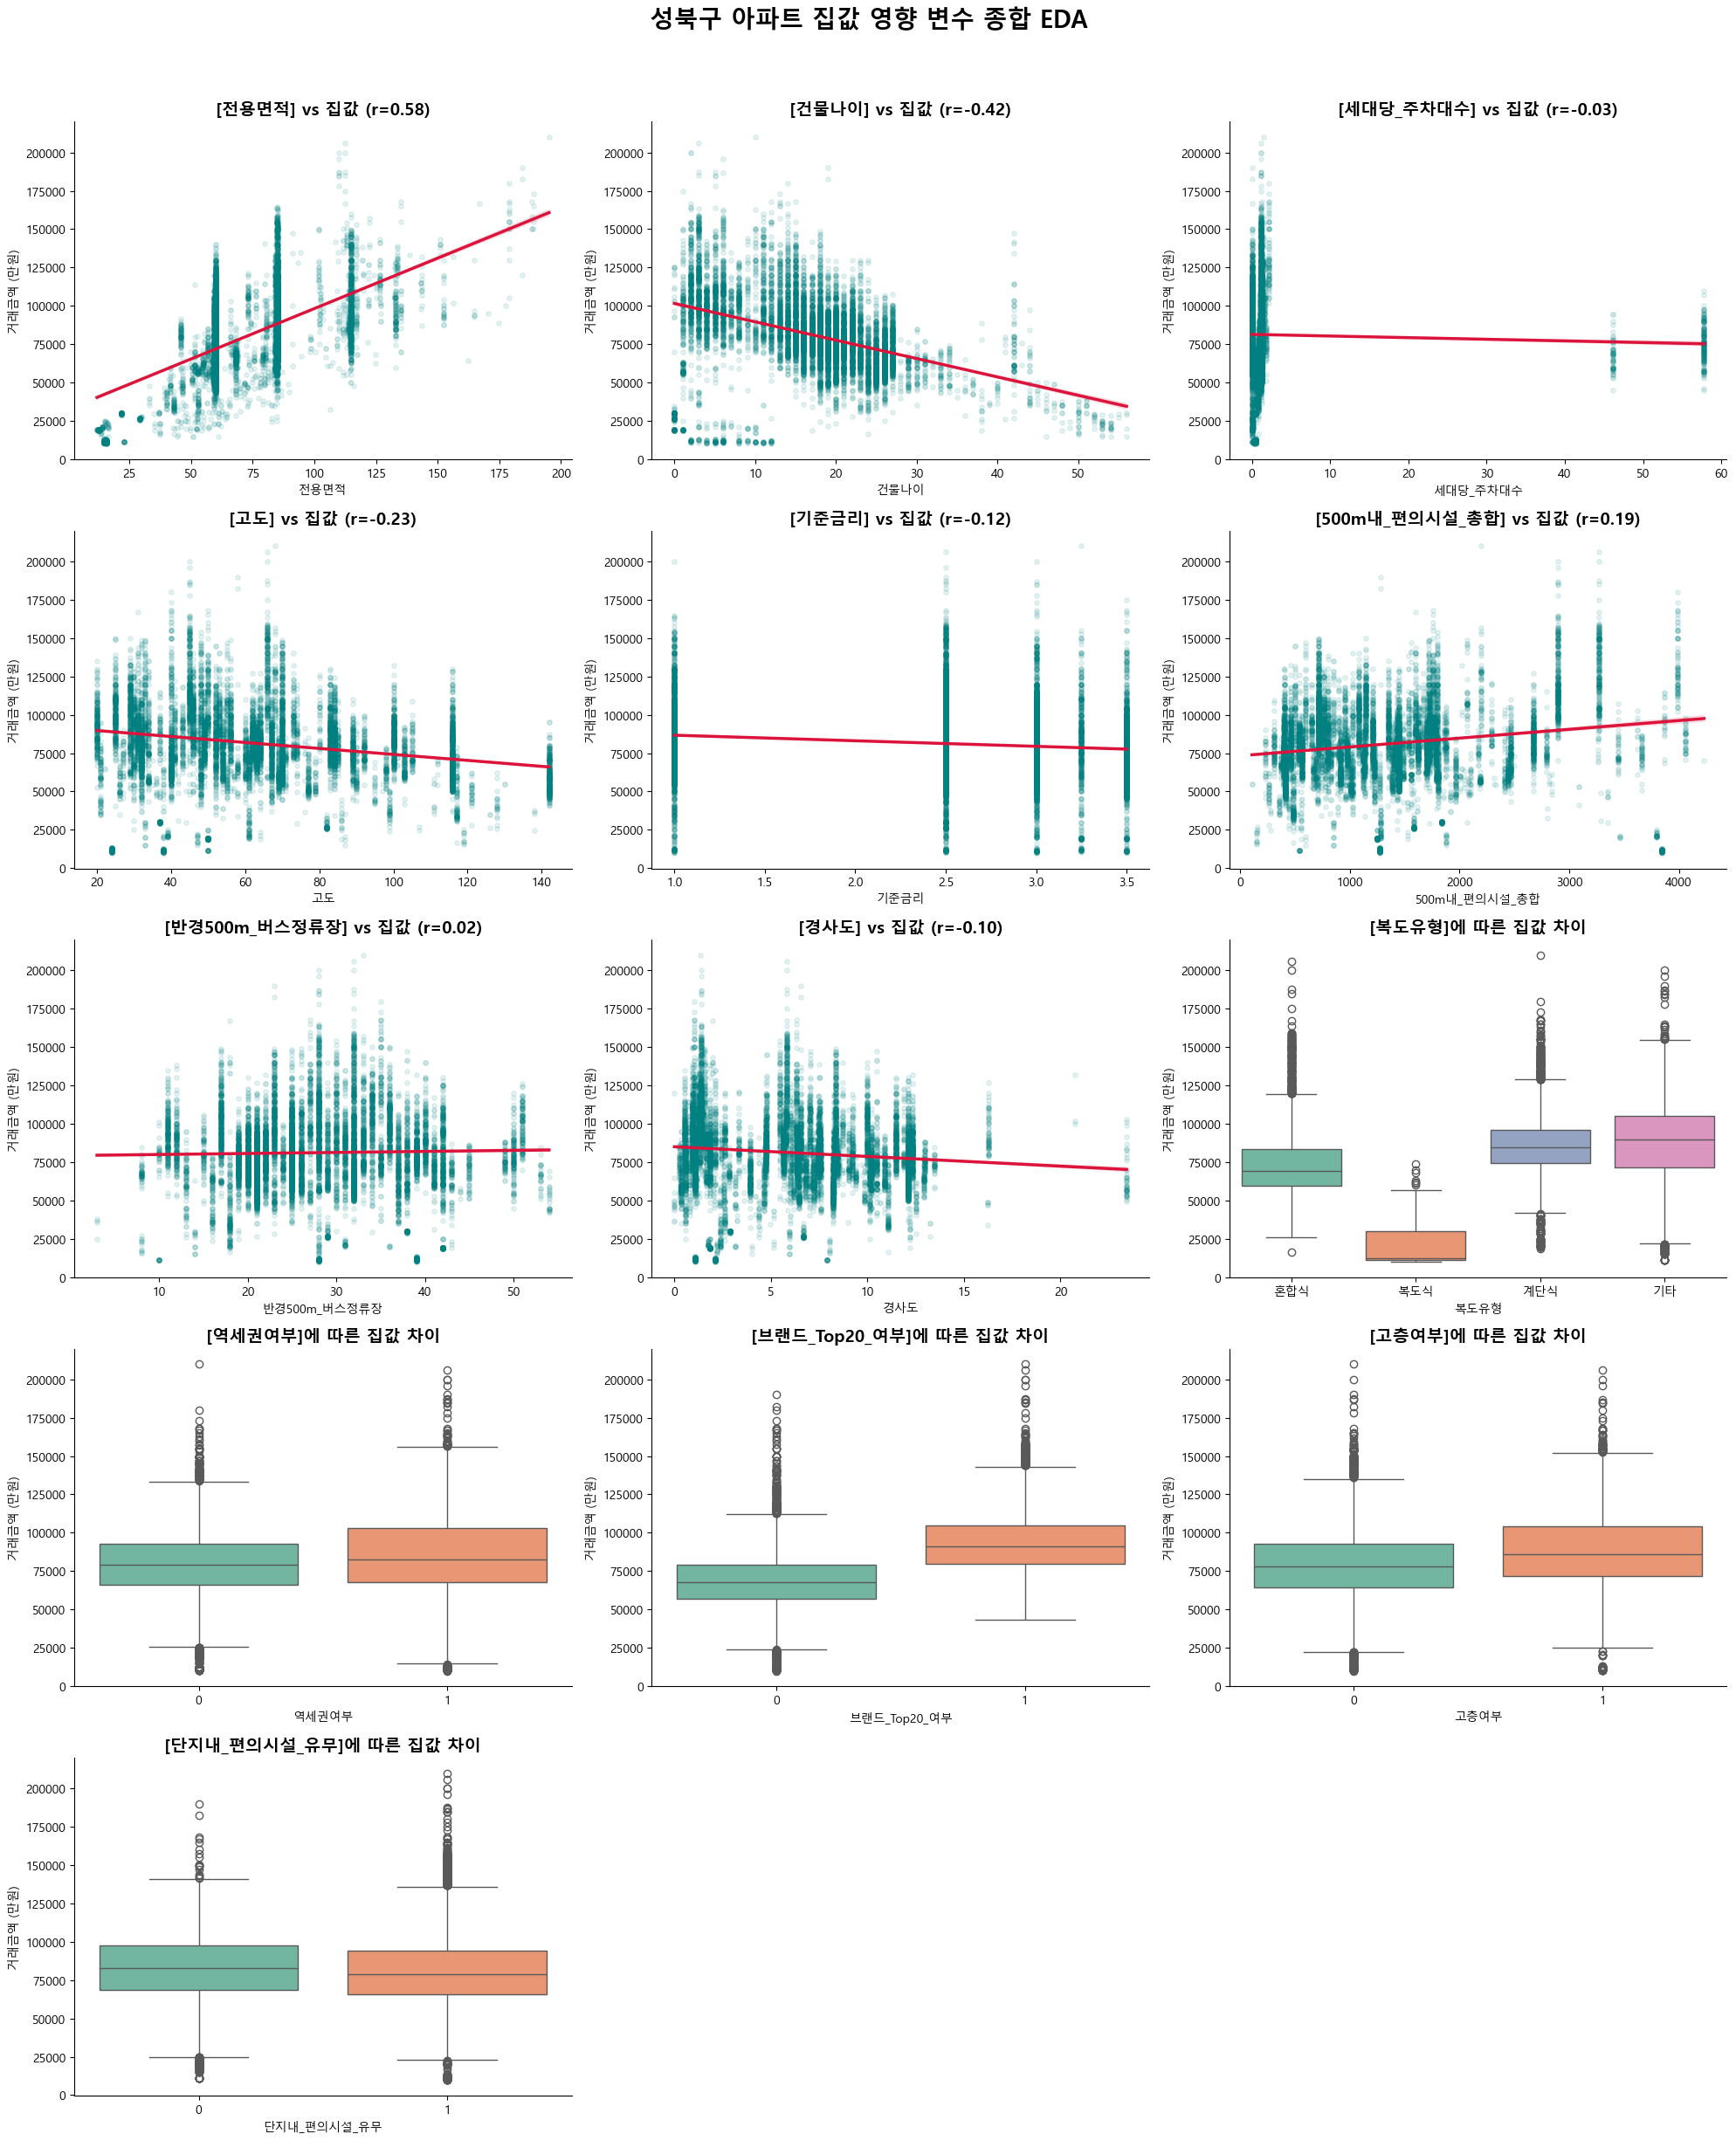

In [4]:
# 4. 13개 핵심 변수 vs 집값 관계 종합 대시보드 생성
print("핵심 변수 종합 EDA 대시보드를 생성합니다...")

# 5행 3열의 대시보드 도화지 준비 (총 15칸)
fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(20, 24))
axes = axes.flatten()

# 박스플롯으로 그릴 범주형(그룹) 변수 목록
categorical_vars = ['복도유형', '역세권여부', '브랜드_Top20_여부', '고층여부', '단지내_편의시설_유무']

for i, var in enumerate(valid_features):
    ax = axes[i]
    
    # 결측치 임시 제거 후 복사본으로 시각화 (원본 보호)
    plot_data = df.dropna(subset=[var, target]).copy()
    
    if var in categorical_vars:
        # 범주형: 박스플롯(Boxplot)
        sns.boxplot(x=var, y=target, data=plot_data, ax=ax, palette='Set2')
        ax.set_title(f'[{var}]에 따른 집값 차이', fontsize=14, fontweight='bold')
    else:
        # 수치형: 산점도(Scatter) + 추세선(Regplot)
        sns.regplot(x=var, y=target, data=plot_data, ax=ax, 
                    scatter_kws={'alpha':0.1, 'color':'teal', 's':15}, 
                    line_kws={'color':'crimson', 'linewidth':2.5})
        
        # 상관계수 계산해서 제목에 추가
        if plot_data[var].nunique() > 1:
            corr = plot_data[var].corr(plot_data[target])
            ax.set_title(f'[{var}] vs 집값 (r={corr:.2f})', fontsize=14, fontweight='bold')
        else:
            ax.set_title(f'[{var}] vs 집값 (변화 없음)', fontsize=14, fontweight='bold')
        
    ax.set_ylabel('거래금액 (만원)')
    ax.set_xlabel(var)
    
    # 깔끔한 디자인을 위해 우측/상단 테두리 제거
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

# 남는 빈 그래프 공간 숨기기
for j in range(len(valid_features), len(axes)):
    fig.delaxes(axes[j])

# 대시보드 전체 제목 및 여백 조정
plt.suptitle('성북구 아파트 집값 영향 변수 종합 EDA', fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import platform
import warnings
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

warnings.filterwarnings('ignore')

# 1. 폰트 및 시각화 기본 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

print("라이브러리 호출 및 환경 설정 완료")

라이브러리 호출 및 환경 설정 완료


In [6]:
# 2. 데이터 불러오기
print("데이터를 불러오는 중입니다...")
df = pd.read_csv('final_dataset.csv', low_memory=False)

print(f"데이터 불러오기 완료 (총 {len(df):,}건)")

데이터를 불러오는 중입니다...
데이터 불러오기 완료 (총 12,454건)


In [7]:
# 3. 데이터 정제 및 독립/종속 변수 설정
if '단지내_편의시설_유무' not in df.columns and '부대복리시설' in df.columns:
    df['단지내_편의시설_유무'] = df['부대복리시설'].apply(
        lambda x: 0 if pd.isna(x) or str(x).strip().lower() == 'nan' else 1
    )

if '복도유형' in df.columns:
    df['복도유형'] = df['복도유형'].astype(str).str.strip() 
    df.loc[~df['복도유형'].isin(['계단식', '복도식', '혼합식']), '복도유형'] = '기타'

# 시간순 정렬을 위해 '계약년월'을 임시로 포함합니다.
features = [
    '전용면적', '건물나이', '세대당_주차대수', '고도', '경사도',     
    '기준금리', '500m내_편의시설_총합', '층', '반경500m_버스정류장', 
    '역세권여부', '브랜드_Top20_여부', '고층여부', '단지내_편의시설_유무',
    '복도유형', '계약년월' 
]

valid_features = [f for f in features if f in df.columns]
X = df[valid_features].copy()
y = df['거래금액_만원']

# 결측치 방어
num_cols = X.select_dtypes(include=[np.number]).columns
X[num_cols] = X[num_cols].fillna(0)

print("기본 변수 세팅 완료")

기본 변수 세팅 완료


In [8]:
# 4. 범주형 변수(복도유형) 원-핫 인코딩 
# (모델이 복도식=1, 계단식=2 처럼 크기로 오해하지 않도록 쪼개기)
if '복도유형' in X.columns:
    X = pd.get_dummies(X, columns=['복도유형'], drop_first=False)
    
print(f"원-핫 인코딩 완료 (현재 독립변수 총 {len(X.columns)-1}개)")

원-핫 인코딩 완료 (현재 독립변수 총 17개)


In [9]:
# 5. 시간순(계약년월) 정렬 후 8:2 분할
if '계약년월' in X.columns:
    # 오름차순(과거->최신) 정렬
    temp_df = pd.concat([X, y], axis=1).sort_values('계약년월')
    
    # 모델 학습에 불필요한 계약년월 제거
    y_sorted = temp_df['거래금액_만원']
    X_sorted = temp_df.drop(columns=['계약년월', '거래금액_만원'])
    
    # 순서를 유지하며 8:2 분할
    X_train, X_test, y_train, y_test = train_test_split(
        X_sorted, y_sorted, test_size=0.2, shuffle=False
    )
    
    split_point = temp_df['계약년월'].iloc[len(X_train)]
else:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
print(f"훈련(Train): {len(X_train):,}건 | 테스트(Test): {len(X_test):,}건")

훈련(Train): 9,963건 | 테스트(Test): 2,491건


In [10]:
# 6. 머신러닝 학습 (과적합 방지 파라미터 적용)
print("최적화된 랜덤 포레스트 모델 학습을 시작합니다...")

rf_final = RandomForestRegressor(
    n_estimators=200, 
    max_depth=15,             
    min_samples_split=10,     
    min_samples_leaf=5,       
    random_state=42, 
    n_jobs=-1
)
rf_final.fit(X_train, y_train) 

# 실전 정확도 평가
rf_pred = rf_final.predict(X_test)
final_r2 = r2_score(y_test, rf_pred)
print(f"최종 모델 실전 예측 정확도 (Test R2 Score) : {final_r2:.4f}")

최적화된 랜덤 포레스트 모델 학습을 시작합니다...
최종 모델 실전 예측 정확도 (Test R2 Score) : 0.9133


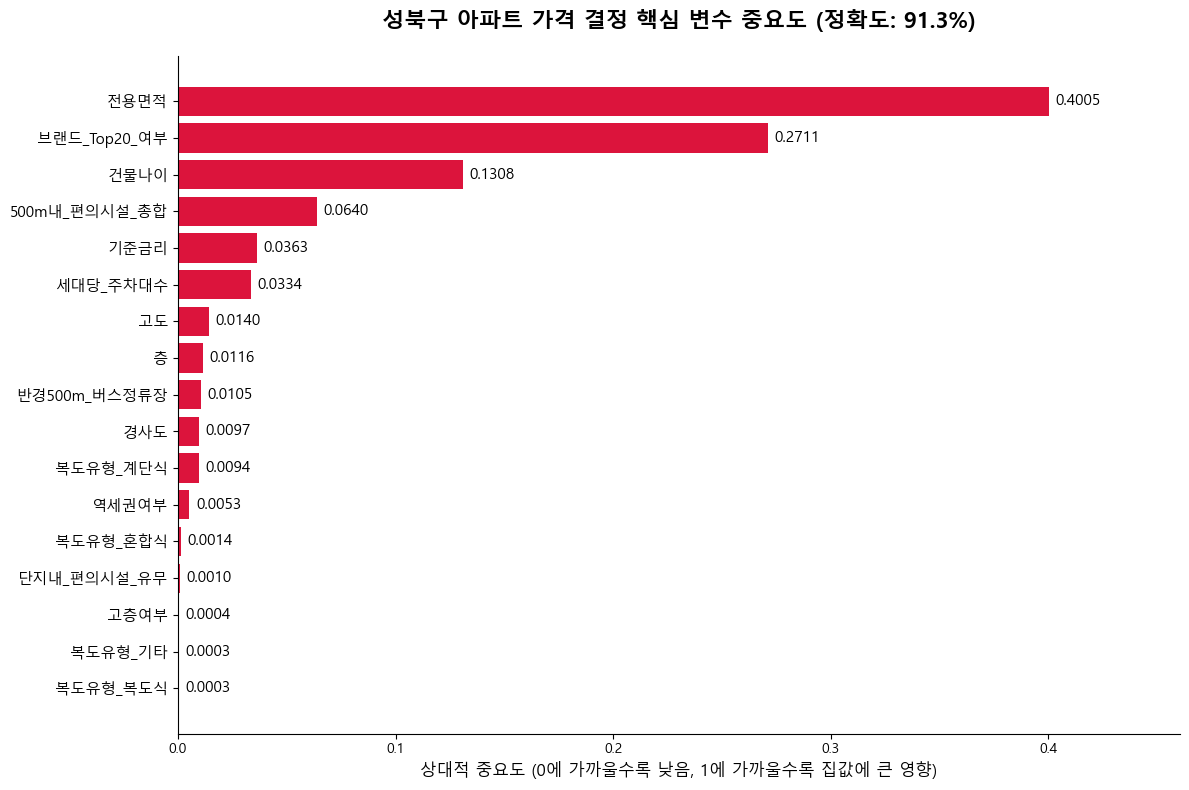

In [11]:
# 7. 변수 중요도 최종 랭킹 시각화
importances = rf_final.feature_importances_
feature_names = X_train.columns
indices = np.argsort(importances)

plt.figure(figsize=(12, 8))
plt.title(f'성북구 아파트 가격 결정 핵심 변수 중요도 (정확도: {final_r2*100:.1f}%)', fontsize=16, fontweight='bold', pad=20)

bars = plt.barh(range(len(indices)), importances[indices], color='crimson', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices], fontsize=11)
plt.xlabel('상대적 중요도 (0에 가까울수록 낮음, 1에 가까울수록 집값에 큰 영향)', fontsize=12)

for i, idx in enumerate(indices):
    plt.text(importances[idx] + 0.003, i, f'{importances[idx]:.4f}', va='center', fontsize=11)

ax = plt.gca()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.xlim(0, max(importances) * 1.15) 
plt.tight_layout()
plt.show()